# Toy Financial Network: Tipping Simulation and Stability Analysis

This notebook simulates a toy financial network where increasing market coupling (ε) induces a critical transition (tipping) from a healthy to a crashed state. It:
- Builds a sparse scale-free network (Barabási–Albert)
- Defines the ODE: dx/dt = r x ∘ (1 − x/K) − ε A x
- For each ε: relaxes to steady state (warm-start), computes Mean Health and Re(λ_max(J))
- Plots Mean Health (blue) and Re(λ) (green) vs ε and marks the tipping point (Re(λ)=0)

Reproducible, minimal, and aligned with `context.md`.


In [266]:
# Imports and parameters (reproducible)
import numpy as np
import numpy.linalg as npl
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.integrate import solve_ivp
import networkx as nx
import matplotlib.pyplot as plt

# Reproducibility
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Model parameters
N = 300                 # number of firms (nodes)
m_ba = 2                # BA model parameter: edges per new node (>=1)
r = 1.0                 # intrinsic growth rate
K = 1.0                 # carrying capacity

# Coupling scale (multiplies ε)
coupling_scale = 1.0

# Epsilon sweep
epsilon_min = 0.0
epsilon_max = 0.1
num_eps = 60

# Steady-state relaxation parameters
max_time = 200.0        # upper bound time for integrator (if using ODE)
max_iter = 20000        # upper bound iterations (if using discrete relaxation)
dt = 0.02               # step size for explicit relaxation
abs_tol = 1e-8          # convergence threshold on step change

# Transient dynamics parameters (post-instability crash simulation)
transient_time = 150.0  # time to run transient dynamics after tipping (longer for crash)
transient_dt = 0.01    # time step for transient integration
perturbation_size = 0.01  # small perturbation to trigger instability at tipping point

# Plotting constraint: max steps to show after crash (tipping)
max_steps_after_crash = 7

# Plot style
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


In [ ]:
# Network generation (Barabási–Albert) and sparse adjacency
G = nx.barabasi_albert_graph(n=N, m=m_ba, seed=RNG_SEED)

# Build adjacency as CSR sparse matrix (row i has neighbors j with A_ij = 1)
A = nx.to_scipy_sparse_array(G, format="csr", dtype=float)

# Optionally normalize coupling by node degree to prevent trivial blow-ups
# Here we use simple unnormalized adjacency to keep the model aligned with context.md

print(A.shape, A.nnz, "(rows, nonzeros)")


(300, 300) 1192 (rows, nonzeros)


In [268]:
# ODE dynamics and steady-state relaxation

def rhs(x: np.ndarray, epsilon: float) -> np.ndarray:
    # dx/dt = r x (1 - x/K) - epsilon A x
    growth = r * x * (1.0 - x / K)
    coupling = (epsilon * coupling_scale) * (A @ x)  # strengthened coupling
    return growth - coupling


def relax_to_steady_state(epsilon: float, x0: np.ndarray) -> np.ndarray:
    """Relax using explicit steps until convergence in L2 norm of updates.
    Warm-starts from x0; clamps to [0, K] to enforce feasibility.
    """
    x = x0.copy()
    for _ in range(max_iter):
        dx = rhs(x, epsilon)
        x_new = x + dt * dx
        # clamp to [0, K]
        np.clip(x_new, 0.0, K, out=x_new)
        if npl.norm(x_new - x) < abs_tol:
            return x_new
        x = x_new
    return x  # best effort


def run_transient_dynamics(epsilon: float, x0: np.ndarray, duration: float, 
                           add_perturbation: bool = False) -> np.ndarray:
    """Run transient ODE dynamics forward in time from x0.
    Returns the final state after duration time units.
    Uses explicit Euler with clamping to [0, K].
    If add_perturbation=True, adds a small random perturbation to trigger instability.
    """
    x = x0.copy()
    if add_perturbation:
        # Add small random perturbation to trigger instability
        perturbation = rng.normal(0.0, perturbation_size, size=N)
        x = np.clip(x + perturbation, 0.0, K)
    
    num_steps = int(duration / transient_dt)
    for _ in range(num_steps):
        dx = rhs(x, epsilon)
        x_new = x + transient_dt * dx
        np.clip(x_new, 0.0, K, out=x_new)
        x = x_new
    return x


In [269]:
# Jacobian and dominant eigenvalue (real part)

def jacobian(x: np.ndarray, epsilon: float) -> sp.csr_matrix:
    # J(x; ε) = diag(r (1 − 2 x / K)) − ε A
    diag_vals = r * (1.0 - 2.0 * x / K)
    D = sp.diags(diag_vals, format="csr")
    return D - ((epsilon * coupling_scale) * A)


def dominant_eig_real_part(J: sp.csr_matrix) -> float:
    # Try sparse eigs for largest real part; fall back to dense if needed
    try:
        vals = spla.eigs(J, k=1, which="LR", return_eigenvectors=False)
        return float(np.real(vals[0]))
    except Exception:
        J_dense = J.toarray()
        vals = npl.eigvals(J_dense)
        return float(np.max(np.real(vals)))


In [270]:
# Epsilon sweep: run actual dynamics at each epsilon (like the paper does)
# We track actual system state from time series, not fixed points

epsilon_values = np.linspace(epsilon_min, epsilon_max, num_eps)
mean_health = np.zeros_like(epsilon_values)
dom_eig_real = np.zeros_like(epsilon_values)

# Initial condition: start from healthy state
x_init = rng.uniform(low=0.8 * K, high=0.95 * K, size=N)

# Time parameters for actual dynamics simulation
simulation_time = 100.0  # total time to run dynamics at each epsilon
simulation_dt = 0.01     # time step for simulation
burn_in_time = 20.0      # initial time to discard (let system settle)
measurement_time = simulation_time - burn_in_time  # time over which we measure

print("Running actual dynamics at each epsilon (following paper approach)...")

for i, eps in enumerate(epsilon_values):
    # Run actual ODE dynamics forward in time
    x_current = x_init.copy()
    
    # Burn-in phase: let system evolve
    burn_in_steps = int(burn_in_time / simulation_dt)
    for _ in range(burn_in_steps):
        dx = rhs(x_current, eps)
        x_new = x_current + simulation_dt * dx
        np.clip(x_new, 0.0, K, out=x_new)
        x_current = x_new
    
    # Measurement phase: collect data and compute metrics
    measurement_steps = int(measurement_time / simulation_dt)
    health_samples = []
    
    for _ in range(measurement_steps):
        dx = rhs(x_current, eps)
        x_new = x_current + simulation_dt * dx
        np.clip(x_new, 0.0, K, out=x_new)
        x_current = x_new
        # Sample mean health during measurement phase
        health_samples.append(float(np.mean(x_current)))
    
    # Mean Health: average over measurement phase (actual system state)
    mean_health[i] = np.mean(health_samples)
    
    # Re(λ): compute from actual final state (not fixed point)
    J = jacobian(x_current, eps)
    dom_eig_real[i] = dominant_eig_real_part(J)
    
    # Warm-start next epsilon from current state
    x_init = x_current.copy()

# Find tipping point: where Re(λ) crosses 0
idx_cross = None
for i in range(1, len(dom_eig_real)):
    if dom_eig_real[i-1] < 0.0 <= dom_eig_real[i]:
        idx_cross = i
        break

if idx_cross is not None:
    x1, y1 = epsilon_values[idx_cross - 1], dom_eig_real[idx_cross - 1]
    x2, y2 = epsilon_values[idx_cross], dom_eig_real[idx_cross]
    if y2 != y1:
        eps_c = x1 + (0.0 - y1) * (x2 - x1) / (y2 - y1)
    else:
        eps_c = epsilon_values[idx_cross]
    print(f"Tipping point at ε_c ≈ {eps_c:.6f}")
else:
    eps_c = None
    print("No tipping point found in the ε range")

# Build sliced arrays for plotting: up to max_steps_after_crash steps after the crash
if idx_cross is not None:
    last_idx = min(len(epsilon_values) - 1, idx_cross + max_steps_after_crash)
else:
    last_idx = len(epsilon_values) - 1

plot_eps = epsilon_values[: last_idx + 1]
plot_mean_health = mean_health[: last_idx + 1]
plot_dom_eig_real = dom_eig_real[: last_idx + 1]


Running actual dynamics at each epsilon (following paper approach)...
Tipping point at ε_c ≈ 0.003966


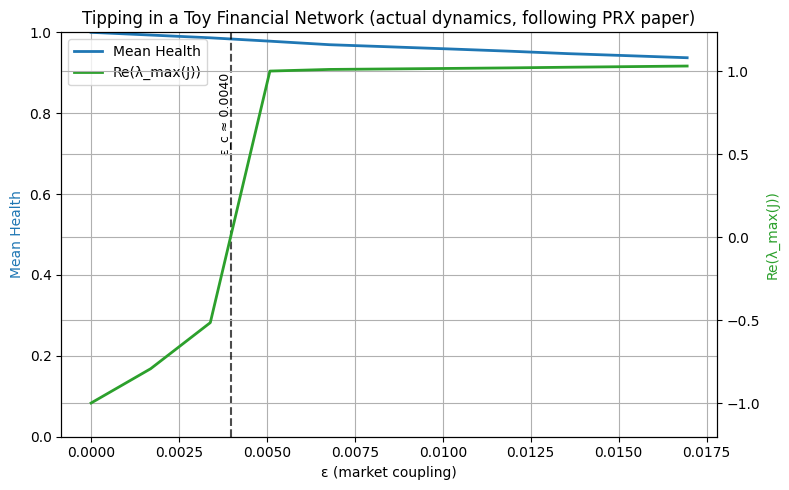

In [ ]:
# Visualization: Mean Health (blue) and Re(λ) (green) vs ε
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(plot_eps, plot_mean_health, color="tab:blue", label="Mean Health", linewidth=2)
ax2.plot(plot_eps, plot_dom_eig_real, color="tab:green", label="Re(λ_max(J))", linewidth=2)

ax1.set_xlabel("ε (market coupling)")
ax1.set_ylabel("Mean Health", color="tab:blue")
ax2.set_ylabel("Re(λ_max(J))", color="tab:green")

# Fix y-axis scaling: keep Mean Health on [0, K]
ax1.set_ylim(0.0, K)
ax2.margins(y=0.1)

# Tipping point line
if eps_c is not None:
    ax1.axvline(eps_c, color="black", linestyle="--", alpha=0.7, linewidth=1.5)
    ax1.text(eps_c, ax1.get_ylim()[1]*0.9, f"ε_c ≈ {eps_c:.4f}", rotation=90,
             va="top", ha="right", fontsize=9, color="black")

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Tipping in a Toy Financial Network (actual dynamics, following PRX paper)")
plt.tight_layout()
plt.show()


## What is happening (conceptual walkthrough)

- **System**: Each node is a firm with health `x_i ≥ 0`. Intrinsic dynamics are logistic (recover toward capacity `K` at rate `r`). The network couples firms via adjacency `A` so stress propagates with strength `ε`.
- **ODE**: `dx/dt = r x ∘ (1 − x/K) − ε A x`. The first term grows each firm toward `K` when small; the second term transmits stress losses along edges.
- **Stability**: Around a steady state `x*`, the Jacobian is `J = diag(r (1 − 2 x*/K)) − ε A`. The dominant eigenvalue’s real part, `Re(λ_max)`, indicates local stability: negative = stable, zero = critical, positive = unstable.
- **Procedure**: For each `ε`, we warm-start the steady-state solver from the previous `ε`’s solution (continuation). We record Mean Health `H = average(x*)` and `Re(λ_max(J))`.
- **Tipping behavior**: As `ε` increases (stronger market coupling), stability weakens (`Re(λ)` rises). At a critical `ε_c`, `Re(λ)` crosses 0, signaling loss of local stability; the mean health curve shows a sharp decline near this point — a crash.

## Financial-market narrative and ML angle
- **Narrative**: `ε` plays the role of market stress/coupling (e.g., tighter interdependencies, leverage, systemic exposure). When stress is small, local shocks dissipate; as stress grows, the system’s local stability erodes until it tips.
- **Signal to learn**: The green curve `Re(λ)` is an early-warning signal — it drifts toward 0 before the crash in mean health. That gap provides a supervised signal for an ML model to learn early predictors of crashes.
- **Next step (ML)**: Generate many simulations with varied seeds and parameters, extract features (e.g., recent health distribution, degrees, small-ε response), and train a model to predict proximity to tipping (e.g., `sign(Re(λ))`, distance to `ε_c`, or time-to-crash proxies).
